<a href="https://colab.research.google.com/github/Overlord15/Deep-Learning-Lab-IA1/blob/main/speech_emotion_recogniton_ProgrammingAssignment_DLTheoryCourse_TIU2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition (SER) using CNNs and CRNNs Based on Mel Spectrograms and Mel Frequency Cepstral Coefficients (MFCCs).

As humans, recognizing emotions in people is something that depends on body language, facial expressions, and tone of voice. But what if we could recognize emotions in people using a short audio file of their voice? This is what we will try to do in this project.

Recognizing emotions from voice alone is a challenging task. It is not easy for humans to do it, and it is even harder for machines. One reason is that emotions are subjective and not universal. Another reason is that we most often rely on facial expressions and body language to recognize emotions, so relying on voice alone is difficult.

We will be using four datasets in this project:
* [RAVDESS](https://zenodo.org/record/1188976#.X2Q4Z2gzZPY)
* [TESS](https://tspace.library.utoronto.ca/handle/1807/24487)
* [SAVEE](http://kahlan.eps.surrey.ac.uk/savee/)
* [CREMA-D](https://github.com/CheyneyComputerScience/CREMA-D)

We will also be using three different models to classify emotions:
* A Convolutional Neural Network (CNN) trained on the Mel Spectrograms of the audio files.
* A CNN trained on the Mel Frequency Cepstral Coefficients (MFCCs) of the audio files.
* A Convolutional Recurrent Neural Network (CRNN) trained on the Mel Frequency Cepstral Coefficients of the audio files.

Table of Contents:
* [1. Data Collection](#1--data-collection)
* [2. Data Wrangling](#2--data-wrangling)
* [3. Data Exploration, Preparation, and Visualization](#3--data-exploration-preparation-and-visualization)
* [4. Data Preprocessing](#4--data-preprocessing)
* [5.1 Mel Spectrogram CNN Model](#51--mel-spectrogram-cnn-model)
* [5.2 MFCCs CNN Model](#52--mfccs-cnn-model)
* [5.3 MFCCs CRNN Model](#53--mfccs-crnn-model)

## 1- Data Collection

We will be using the kaggle api to automate the process of downloading the datasets. The datasets will each be unzipped to a separate folder.

In [1]:
# Collect CREMA-D audio dataset from Kaggle into a folder called 'cremad'
#!kaggle datasets download -d ejlok1/cremad --unzip -p cremad

In [2]:
# Collect RAVDESS audio dataset from Kaggle into a folder called 'ravdess'
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio --unzip -p ravdess

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:03<00:00, 124MB/s]



In [3]:
# Collect TESS audio dataset from Kaggle
#!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess --unzip

In [4]:
# Collect SAVEE audio dataset from Kaggle into a folder called 'savee'
#!kaggle datasets download -d ejlok1/surrey-audiovisual-expressed-emotion-savee --unzip -p savee

## 2- Data Wrangling

Each of the datasets has a different way of naming the audio files and their labels. Each dataset also has different emotions. So, we will have to do some wrangling to get them all in the same format.

In [5]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
# This allows normalization for the specgrams which allows for clearer visualizations
from matplotlib.colors import Normalize
import seaborn as sns

import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')
# Set style and color palette
sns.set(style='darkgrid', palette='magma')
# Change the setting and put it in a dictionary
plot_settings = {
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'figure.dpi': 140,
    'axes.titlepad': 15,
    'axes.labelpad': 15,
    'figure.titlesize': 24,
    'figure.titleweight': 'bold',
}
# Use the dictionary variable to update the settings using matplotlib
import matplotlib
matplotlib.font_manager.fontManager.addfont.__doc__  # ensure font manager is loaded
plt.rcParams.update(plot_settings)
plt.rcParams['font.family'] = 'DejaVu Sans'  # Explicitly set font to avoid missing font warnings

In [6]:
# Check if GPU is available
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [8]:
# Put the ravdess directory in a list
ravdess = os.listdir('ravdess/audio_speech_actors_01-24/')
# Make a list for emotion labels and a list for path to audio files
emotions = []
paths = []
# Loop through all the actor directories in audio_speech_actors_01-24
for dir in ravdess:
    # Loop through all the files in each directory
    for file in os.listdir('ravdess/audio_speech_actors_01-24/' + dir):
        # Extract the emotion label from the file name
        emotion = file.split('-')[2]
        if emotion == '01':
            emotion = 'neutral'
        elif emotion == '02':
            emotion = 'calm'
        elif emotion == '03':
            emotion = 'happiness'
        elif emotion == '04':
            emotion = 'sadness'
        elif emotion == '05':
            emotion = 'anger'
        elif emotion == '06':
            emotion = 'fear'
        elif emotion == '07':
            emotion = 'disgust'
        elif emotion == '08':
            emotion = 'surprise'
        else:
            emotion = 'Unknown'
        # Extract the path
        path = 'ravdess/audio_speech_actors_01-24/' + dir + '/' + file
        # Append the emotion and path to their lists
        emotions.append(emotion)
        paths.append(path)
# Create a dataframe from the lists
ravdess_df = pd.DataFrame(emotions, columns=['Emotion'])
ravdess_df['Path'] = paths
# Inspect the dataframe
ravdess_df.head()

,Emotion,Path
0,calm,ravdess/audio_speech_actors_01-24/Actor_20/03-...
1,anger,ravdess/audio_speech_actors_01-24/Actor_20/03-...
2,fear,ravdess/audio_speech_actors_01-24/Actor_20/03-...
3,calm,ravdess/audio_speech_actors_01-24/Actor_20/03-...
4,surprise,ravdess/audio_speech_actors_01-24/Actor_20/03-...


# 3- Data Exploration, Preparation, and Visualization

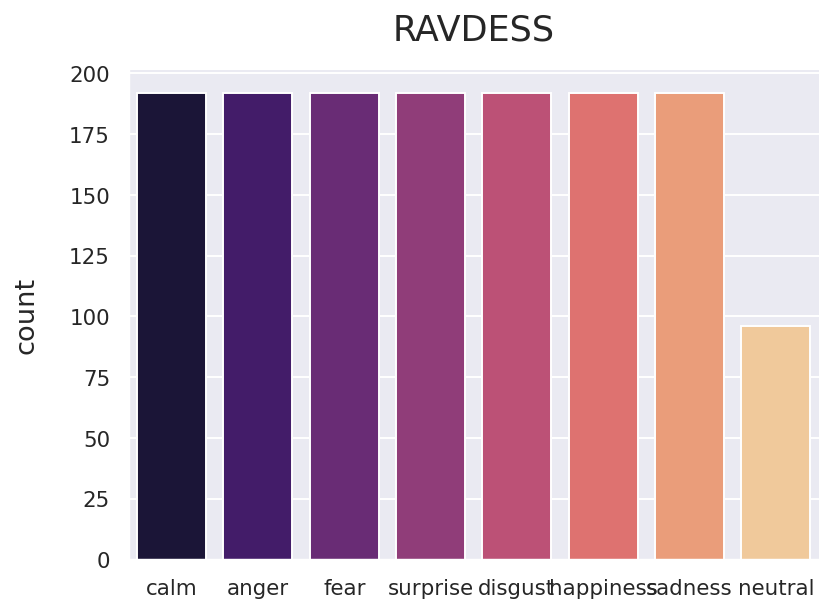

In [11]:
# Plot the value counts for each emotion in each dataset
plt.figure(figsize=(14, 10))
#plt.subplot(2, 2, 1)
#sns.countplot(cremad_df, x = cremad_df['Emotion'], palette='magma')
#plt.title('CREMA-D')
#plt.xlabel('')
plt.subplot(2, 2, 2)
sns.countplot(ravdess_df, x = ravdess_df['Emotion'], palette='magma')
plt.title('RAVDESS')
plt.xlabel('')
#plt.subplot(2, 2, 3)
#sns.countplot(tess_df, x = tess_df['Emotion'], palette='magma')
#plt.title('TESS')
#plt.subplot(2, 2, 4)
#sns.countplot(savee_df, x = savee_df['Emotion'], palette='magma')
#plt.title('SAVEE')
#plt.suptitle('Emotion Counts for Each Dataset')
# Adjust the layout so there are no overlapping titles
#plt.tight_layout(pad=2)
# Remove the spines
sns.despine()
plt.show()

In [12]:
# Count the number of emotions in each dataset
#print('CREMA-D Emotion Counts:')
#print(cremad_df['Emotion'].value_counts())
print('\nRAVDESS Emotion Counts:')
print(ravdess_df['Emotion'].value_counts())
#print('\nTESS Emotion Counts:')
#print(tess_df['Emotion'].value_counts())
#print('\nSAVEE Emotion Counts:')
#print(savee_df['Emotion'].value_counts())


RAVDESS Emotion Counts:
Emotion
calm         192
anger        192
fear         192
surprise     192
disgust      192
happiness    192
sadness      192
neutral       96
Name: count, dtype: int64


As we can see, the datasets are not balanced. The Crema-D dataset has the most number of audio files, and the savee dataset has the least. We will have to balance the datasets before training our models. Fortunately, combining the datasets will give us an adequately balanced dataset.

In [13]:
# Create a dataframe that contains all the emotion labels and paths from all the datasets
#df = pd.concat([cremad_df, ravdess_df, tess_df, savee_df], axis=0)

df = pd.concat([ravdess_df], axis=0)
# Reset the index
df = df.reset_index(drop=True)
# Inspect the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Emotion  1440 non-null   object
 1   Path     1440 non-null   object
dtypes: object(2)
memory usage: 22.6+ KB


In [14]:
# Count the number of emotions in the combined dataframe
df['Emotion'].value_counts()

,count
Emotion,
calm,192
anger,192
fear,192
surprise,192
disgust,192
happiness,192
sadness,192
neutral,96


As expected, the complete dataset is adequately balanced except for the calm, surprise, and neutral emotions. As for the calm emotion, it is extremely similar to the neutral emotion, so we will drop it. Neutral is similar in count to the other emotions, so we will keep it. Surprise would be the only unbalanced emotion, but we will keep it as well, as it is an important emotion to recognize.

In [15]:
# Drop the calm emotion as there are too few samples and it is too similar to neutral
df = df[df['Emotion'] != 'calm']

In [16]:
# Check if it was dropped
df['Emotion'].value_counts()

,count
Emotion,
anger,192
fear,192
surprise,192
disgust,192
happiness,192
sadness,192
neutral,96


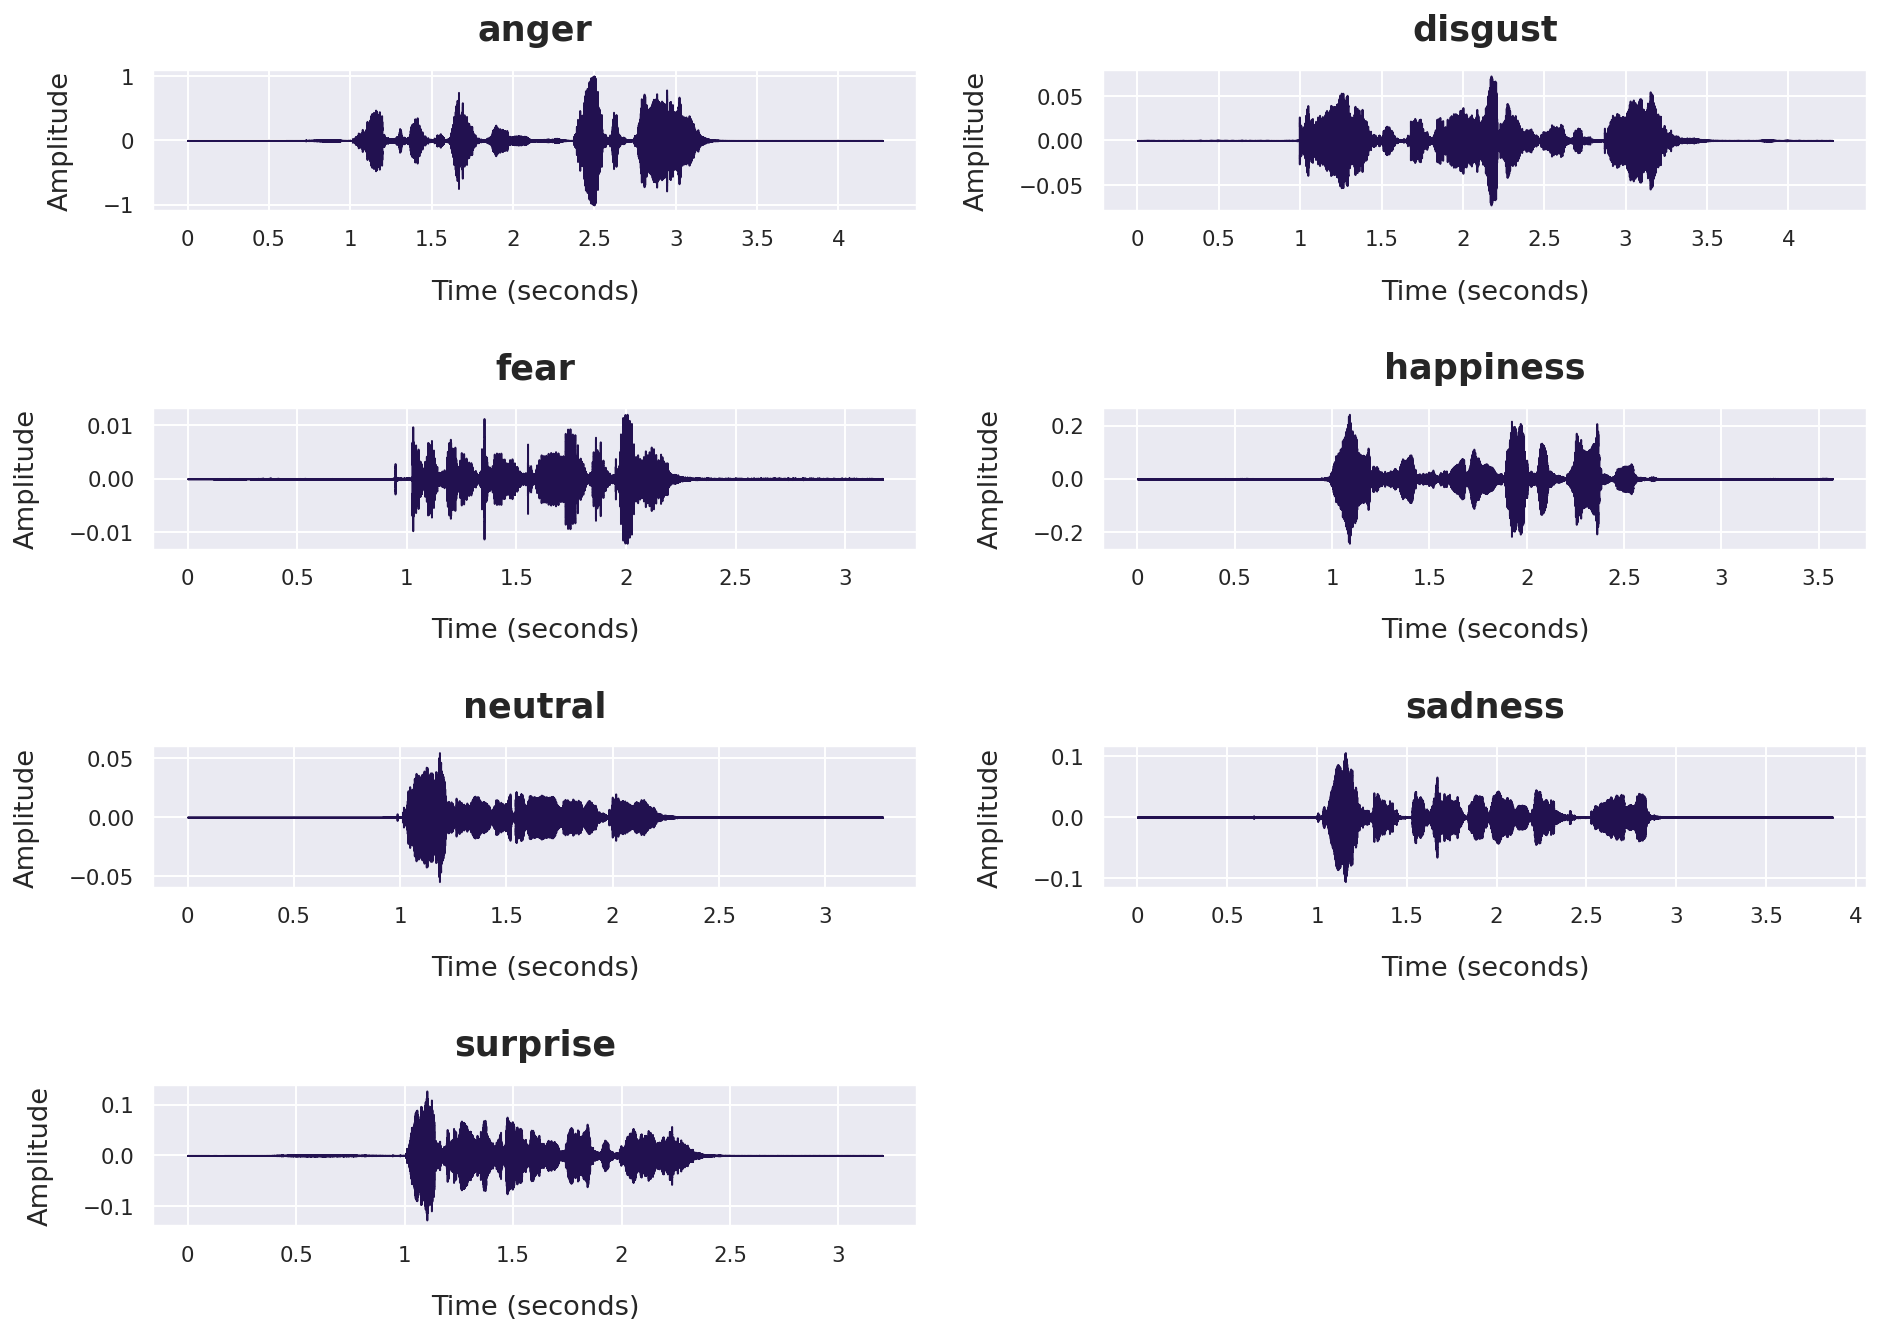

In [17]:
# Get a sample from each emotion type
sample = df.groupby('Emotion', group_keys=False).apply(lambda x: x.sample(1))
# extract the path from the sample
sample_paths = sample['Path'].tolist()
# Create a waveform plot for a sample of each emotion
plt.figure(figsize=(14, 10))
for i in range(7):
    plt.subplot(4, 2, i+1)
    # Load the audio file and set the sampling rate to 44100
    data, sr = librosa.load(sample_paths[i], sr = 44100)
    # Plot the waveform
    librosa.display.waveshow(data, sr=sr)
    # Add a title and make it bold
    plt.title(sample['Emotion'].values[i], fontweight='bold')
    # Add labels to the x and y axes
    plt.ylabel('Amplitude')
    plt.xlabel('Time (seconds)')
# Adjust the layout so there are no overlapping titles
plt.tight_layout(pad=2)

Mel Spectrograms are a visual representation of the spectrum of frequencies of a signal as it varies with time. They are commonly used in speech recognition. We will be using them as input to our CNN model.

They are generated by applying the Short Time Fourier Transform (STFT) to a signal. The STFT is applied to a signal by applying the Fourier Transform to small overlapping windows of the signal.

The Mel Spectrogram is then generated by mapping the power of the signal obtained from the STFT to the mel scale. The mel scale is a scale that relates the perceived frequency of a tone to the actual measured frequency.

The mel scale is logarithmic, so it is more similar to the human auditory system than the linear frequency scale.

The brightness of the spectrogram represents the loudness in decibels of the frequencies at a given time. The y-axis represents the frequencies, and the x-axis represents the time.

This [article](https://towardsdatascience.com/audio-deep-learning-made-simple-part-2-why-mel-spectrograms-perform-better-aad889a93505#:~:text=A%20Mel%20Spectrogram%20makes%20two,of%20Amplitude%20to%20indicate%20colors.) explains the process of generating Mel Spectrograms in more detail


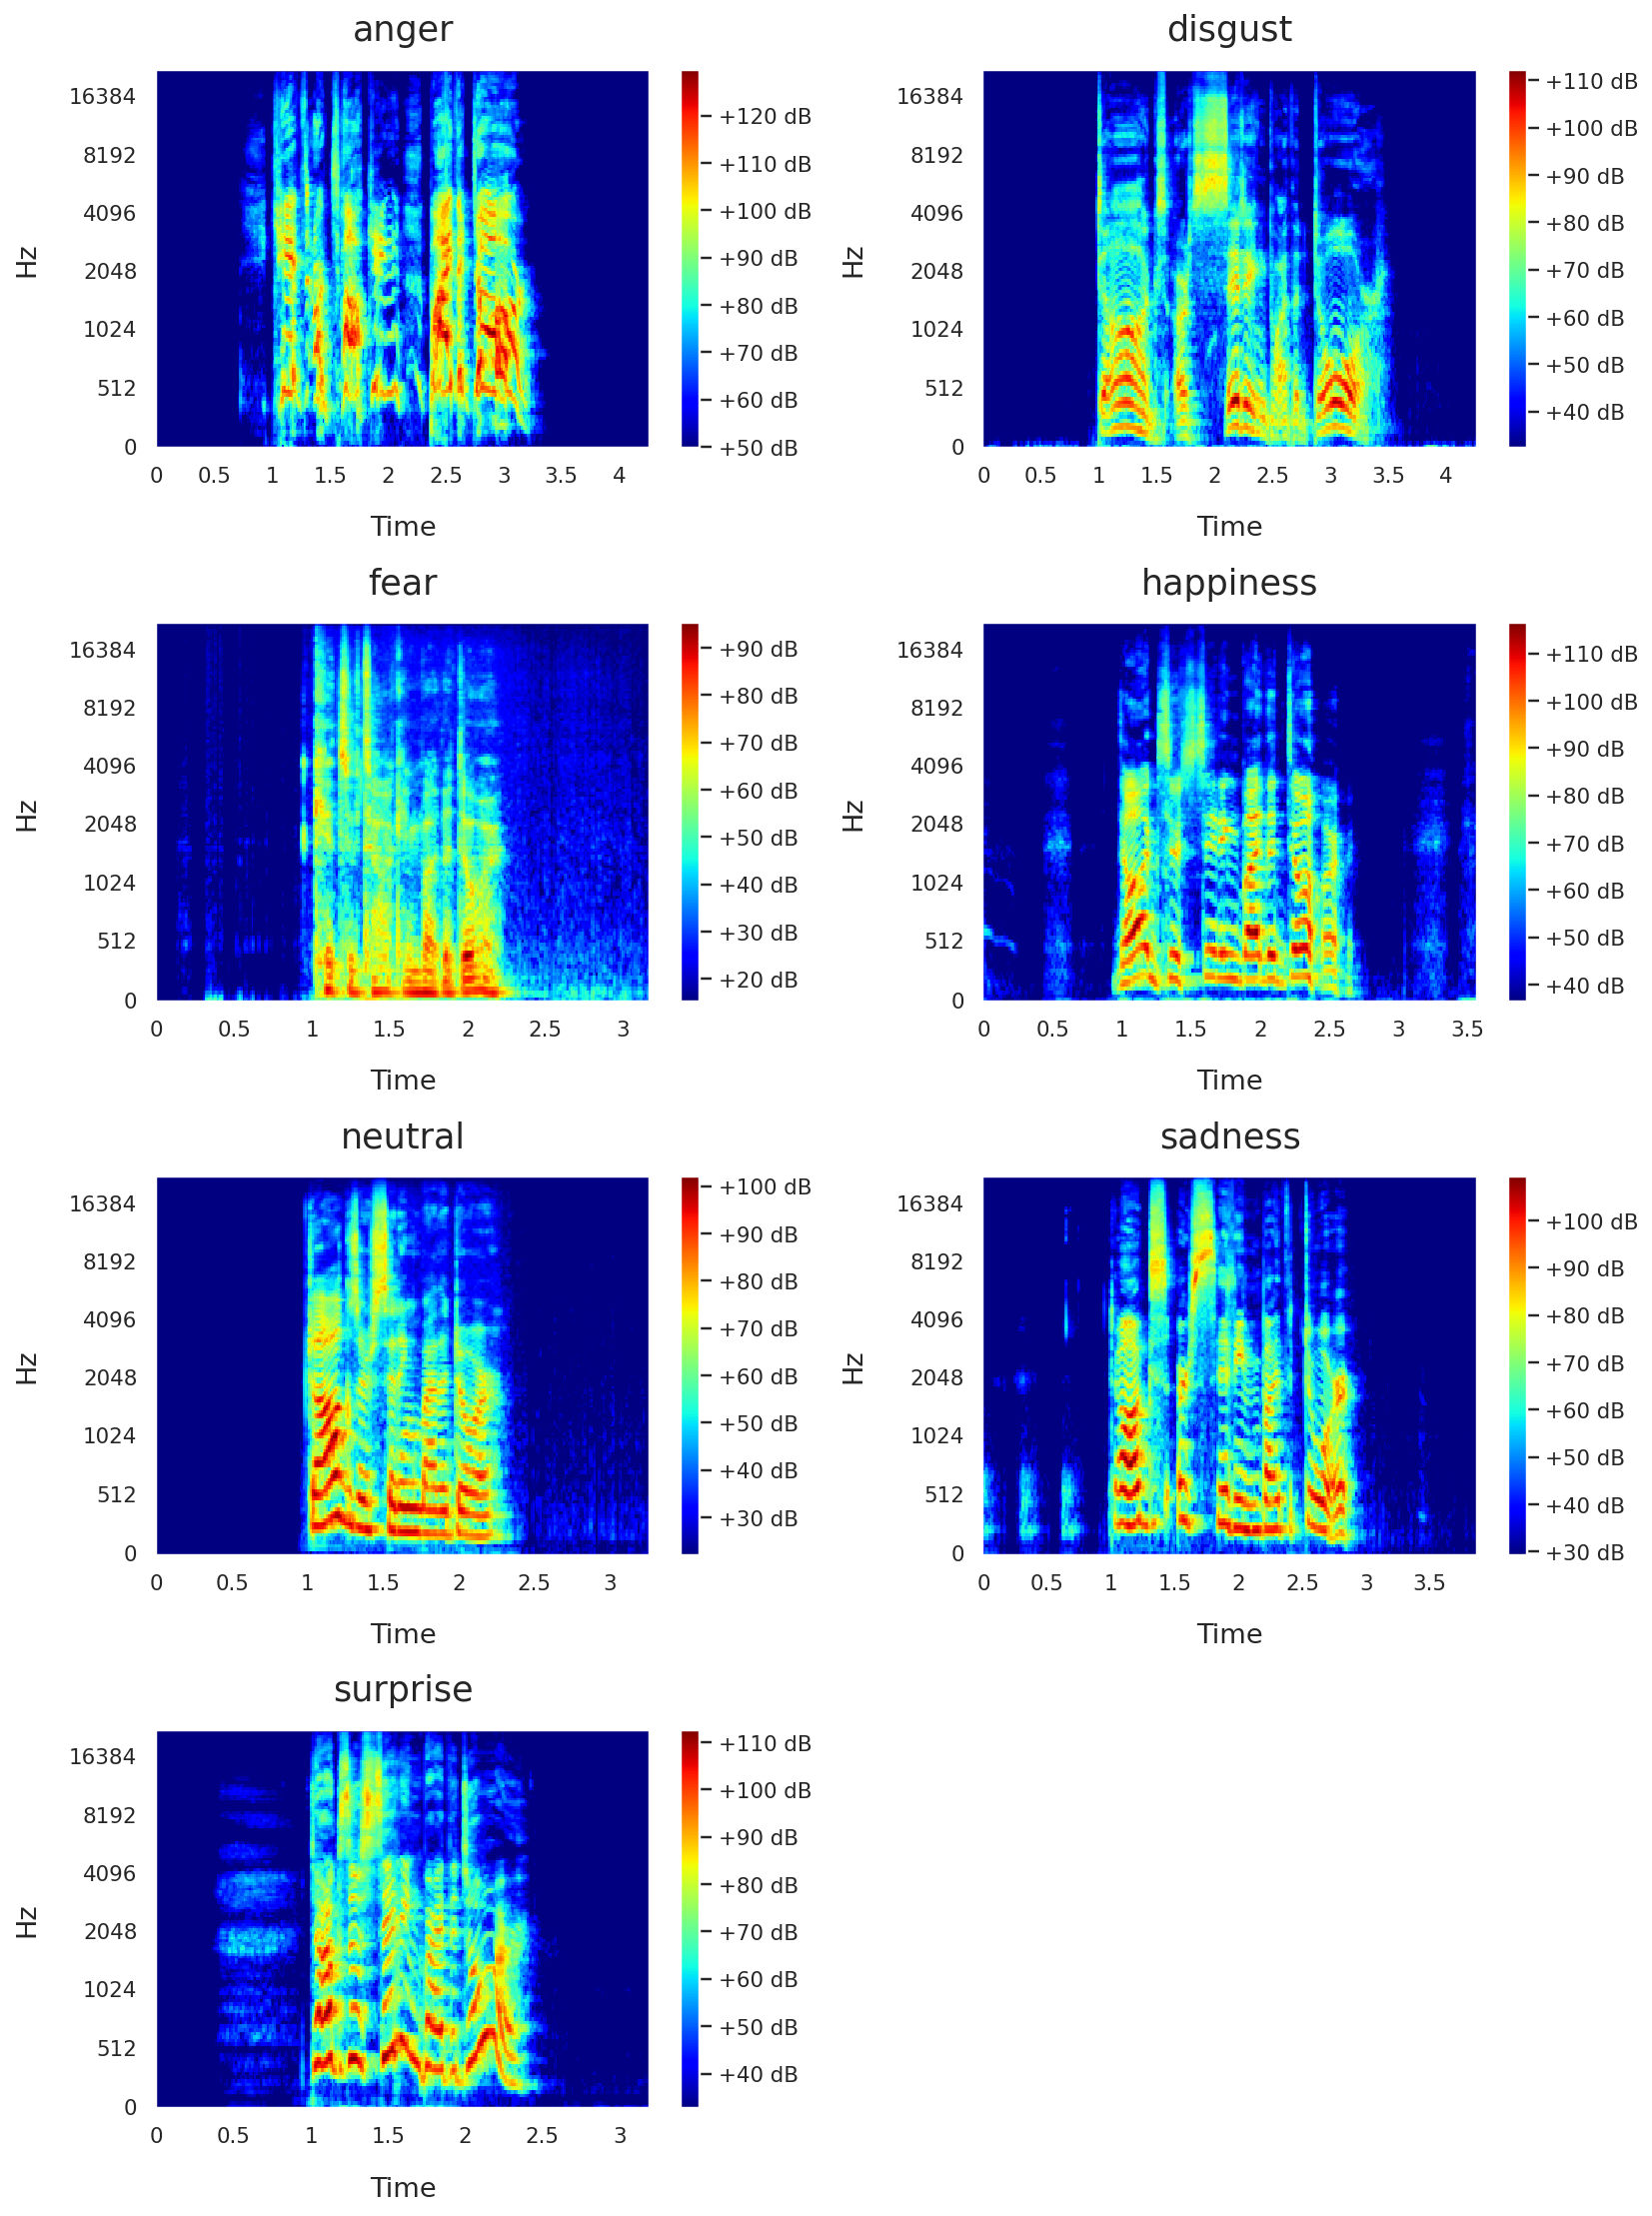

In [18]:
# Create a spectrogram plot for each emotion
plt.figure(figsize=(12, 16))
for i in range(7):
    plt.subplot(4, 2, i+1)
    # Load the audio file, we chose sr = 44100 to standardize the sampling rate
    signal, sr = librosa.load(sample_paths[i], sr=44100)
    # Make the logarithmically scaled mel spectrogram
    signal = librosa.feature.melspectrogram(y = signal, sr=sr)
    # Convert the spectrogram from amplitude squared to decibels
    # as amplitude does not give us much information
    signal = librosa.power_to_db(signal, ref=np.min)
    # Plot the spectrogram
    #librosa.display.specshow(signal, sr=sr, x_axis='time', y_axis='mel')
    librosa.display.specshow(signal, y_axis='mel', sr=sr, x_axis='time', cmap = 'jet')
    plt.title(sample['Emotion'].values[i])
    # Plot a color bar to show the intensity scale from 0 Decibels to the max
    plt.colorbar(format='%+2.0f dB')
plt.tight_layout()


## 4- Data Preprocessing

We will be using the librosa library to extract the Mel Spectrograms from the audio files. We will also be using the sklearn library to split the data into training and testing sets.

In [19]:
# Encode the emotion labels into numbers
encoder = LabelEncoder()
df['Emotion'] = encoder.fit_transform(df['Emotion'])
# Make sure the encoding worked
df['Emotion'].value_counts()

,count
Emotion,
0,192
2,192
6,192
1,192
3,192
5,192
4,96


In [20]:
# Create a function that takes an audio file path and returns the mel spectrogram
# as an image, and converts the image into a numpy array
def process_audio(path):

    #Load the audio file, convert the audio file into a mel spectrogram,
    #return the mel spectrogram as an image, and convert the image into a numpy array

    # Load the audio file and set the sampling rate to 44100
    audio, sr = librosa.load(path, sr=44100, duration=4, mono=True)
    # pad the audio files that are less than 4 seconds with zeros at the end
    if len(audio) < 4 * sr:
        audio = np.pad(audio, pad_width=(0, 4 * sr - len(audio)), mode='constant')
    # Convert the audio file into a mel spectrogram
    signal = librosa.feature.melspectrogram(y = audio, sr=sr, n_mels=128)
    # Convert the spectrogram from amplitude squared to decibels
    # as amplitude does not give us much information
    signal = librosa.power_to_db(signal, ref=np.min)    # Convert the image into a numpy array
    image = np.array(signal)
    # Return the image
    return image


Numpy array shape: (128, 345)


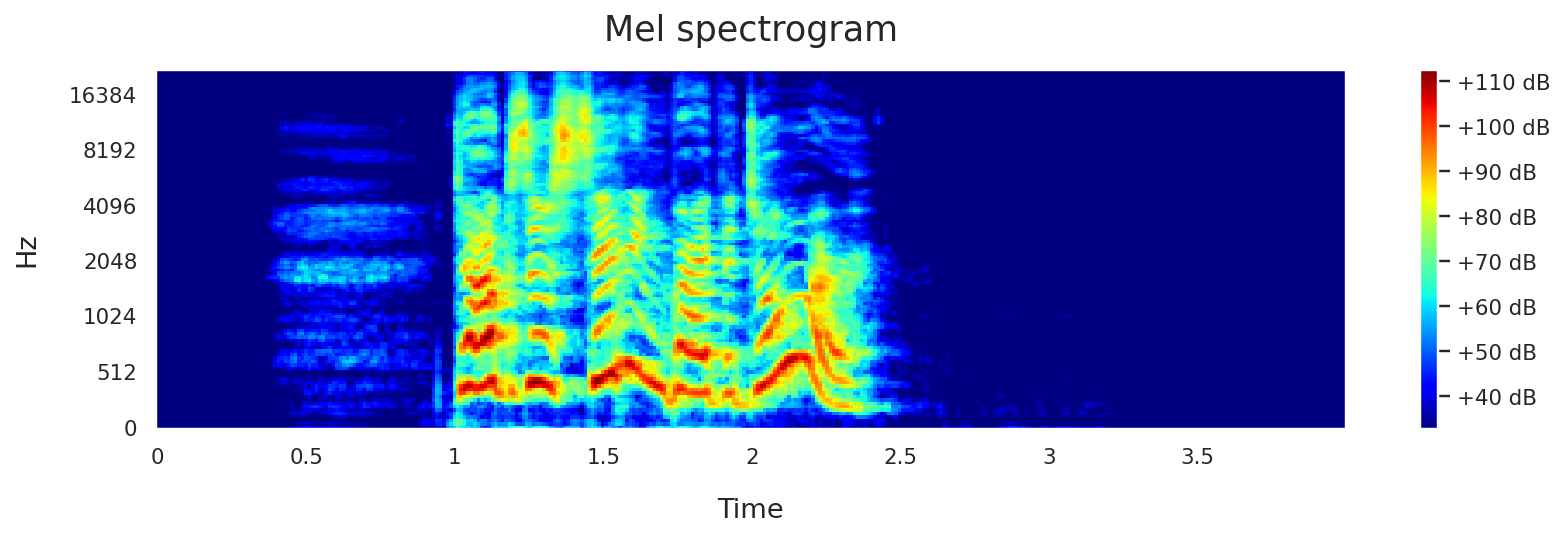

In [21]:
# Test the function on the sample audio file
image = process_audio(sample_paths[6])
# Print the shape of the numpy array
print('Numpy array shape:', image.shape)
# Plot the image
plt.figure(figsize=(12, 4))
#librosa.display.specshow(image, sr=sr, x_axis='time', y_axis='mel')
librosa.display.specshow(image, y_axis='mel', sr=sr, x_axis='time', cmap = 'jet')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel spectrogram')
plt.tight_layout()


In [22]:
# Divide the data into features and labels
X_mel = [process_audio(path) for path in df['Path']]
y_mel = df['Emotion']

In [23]:
# Check the length of the feature and label lists
print('Number of images:', len(X_mel))
print('Number of labels:', len(y_mel))

Number of images: 1248
Number of labels: 1248


Label: 0


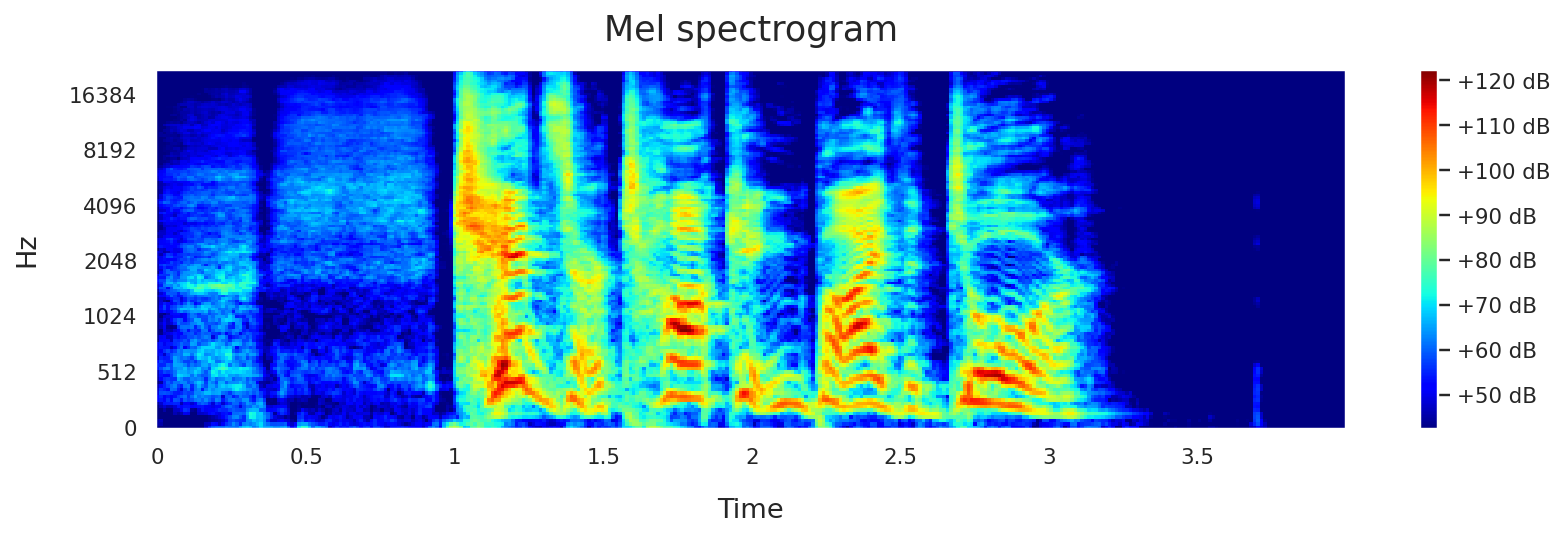

In [24]:
# Plot the first image and its corresponding label
plt.figure(figsize=(12, 4))
#librosa.display.specshow(X_mel[0], sr=sr, x_axis='time', y_axis='mel')
librosa.display.specshow(X_mel[0], y_axis='mel', sr=sr, x_axis='time', cmap = 'jet')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel spectrogram')
plt.tight_layout()
print('Label:', y_mel.iloc[0])

In [25]:
# Divide the data into training and testing sets, with a 80:20 split
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_mel, y_mel,
                                                    test_size=0.2,
                                                    random_state=0,
                                                    shuffle=True)

In [26]:
# Check the length of the training and testing sets
print('Number of training images:', len(X_train_1))
print('Number of testing images:', len(X_test_1))
print('Number of training labels:', len(y_train_1))
print('Number of testing labels:', len(y_test_1))

Number of training images: 998
Number of testing images: 250
Number of training labels: 998
Number of testing labels: 250


In [27]:
# Convert the lists into numpy arrays
X_train_1 = np.array(X_train_1)
X_test_1 = np.array(X_test_1)
y_train_1 = np.array(y_train_1)
y_test_1 = np.array(y_test_1)
# Check the shape of the arrays
print('X_train shape:', X_train_1.shape)
print('X_test shape:', X_test_1.shape)
print('y_train shape:', y_train_1.shape)
print('y_test shape:', y_test_1.shape)

X_train shape: (998, 128, 345)
X_test shape: (250, 128, 345)
y_train shape: (998,)
y_test shape: (250,)


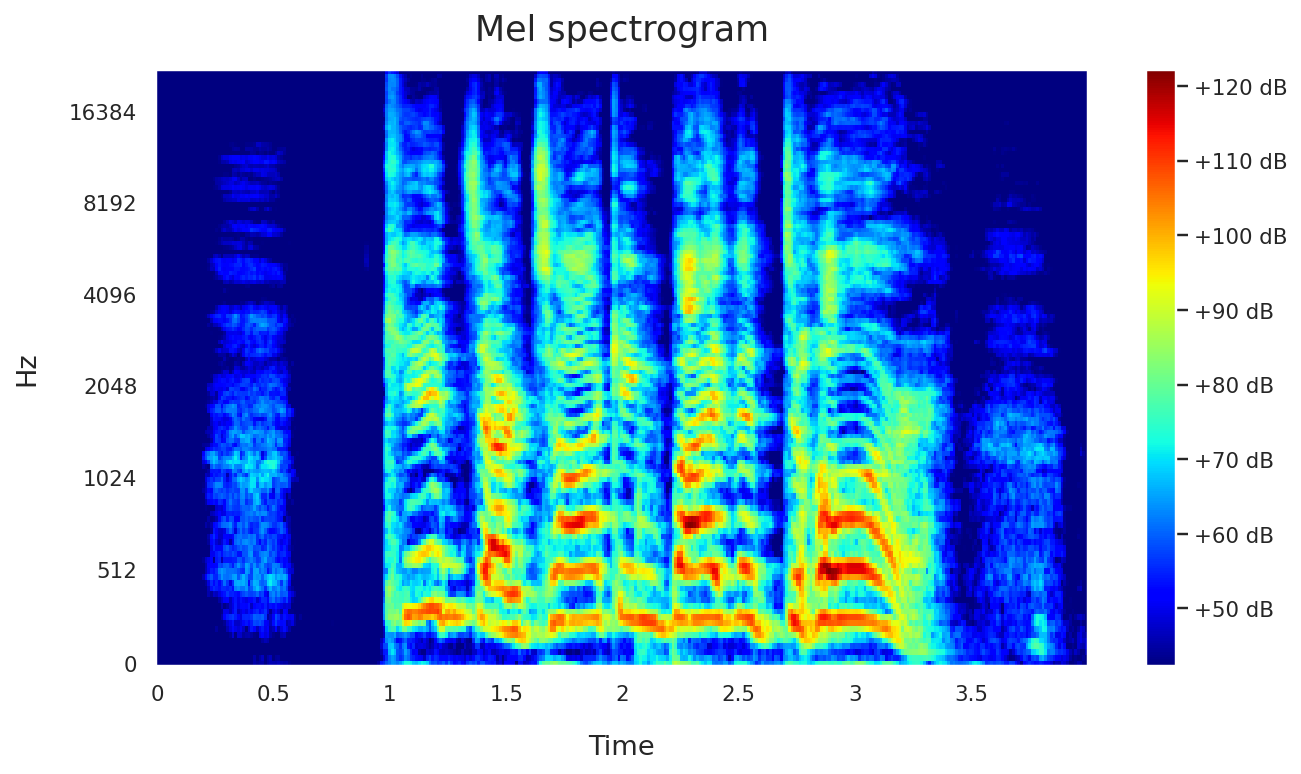

In [28]:
# plot the first image in the training set as a mel spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(X_train_1[0].reshape(128, 345), sr=sr, x_axis='time', y_axis='mel', cmap = 'jet')

plt.colorbar(format='%+2.0f dB')
plt.title('Mel spectrogram')
plt.tight_layout(pad=2)

We should standardize the data by making the mean 0 and standard deviation 1 before feeding it to the model. This will help the model train faster and generalize better.

In [29]:
# Standardize the data by subtracting the mean and dividing by the standard deviation
mean = np.mean(X_train_1)
std = np.std(X_train_1)
X_train_1 = (X_train_1 - mean) / std
X_test_1 = (X_test_1 - mean) / std

In [30]:
# Check the mean and standard deviation
print('Mean:', mean)
print('Standard deviation:', std)
# Check if the data is standardized
print('Mean of standardized data:', np.mean(X_train_1))
print('Standard deviation of standardized data:', np.std(X_train_1))

Mean: 45.856968
Standard deviation: 19.508366
Mean of standardized data: 3.9020238e-06
Standard deviation of standardized data: 1.0000011


In [31]:
# Reshape the data into 4D arrays so that it can be input into the 2D CNN
X_train_1 = X_train_1.reshape(X_train_1.shape[0], 128, 345, 1)
X_test_1 = X_test_1.reshape(X_test_1.shape[0], 128, 345, 1)
# Check the shape of the arrays
print('X_train shape:', X_train_1.shape)
print('X_test shape:', X_test_1.shape)

X_train shape: (998, 128, 345, 1)
X_test shape: (250, 128, 345, 1)


Next, we make a Dataset object from the data. This will allow us to make batches, and prefetch the data, which means that the data will be loaded to the GPU while the model is training on the previous batch. This will make the training process faster.

In [32]:
# Divide the data into batches of 32 images
batch_size = 32
# Make a training dataset from the training set
train_dataset_1 = tf.data.Dataset.from_tensor_slices((X_train_1, y_train_1))
# Shuffle, batch, and prefetch the data
train_dataset_1 = train_dataset_1.batch(batch_size).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
# Make a testing dataset from the testing set
test_dataset_1 = tf.data.Dataset.from_tensor_slices((X_test_1, y_test_1))
# Shuffle, batch, and prefetch the data
test_dataset_1 = test_dataset_1.batch(batch_size).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

## 5- Modeling

### 5.1- Mel Spectrogram CNN Model
We will treat the mel spectrograms as images and use a CNN to classify them. We will use the Adam optimizer and the sparse categorical cross entropy loss function.

# ###### UPDATE THIS PORTION WITH PRETRAINED CNN MODELS TO PERFORM TRANSFER LEARNING AND FINE-TUNING AS DONE IN LAB CLASS. COMMENT OUT THE CODE GIVEN HERE AND ADD A NEW CELL WHERE YOU PASTE YOUR OWN CODE

In [34]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# =========================================================
# (a1) Transfer Learning: ResNet50 Backbone + Custom Head
# =========================================================

# Load pre-trained ResNet50 backbone (ImageNet weights, no top)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)      # ResNet50 expects 224x224 RGB
)

# ── Phase 1: Freeze the entire base model (feature extraction only) ──
for layer in base_model.layers:
    layer.trainable = False

# ── Input & channel adapter ──────────────────────────────────────────
# Spectrogram inputs are grayscale (1 channel); resize & convert to 3-ch
inputs = layers.Input(shape=(128, 345, 1), name='spectrogram_input')

# Resize to (224,224) for ResNet50 compatibility
x = layers.Resizing(224, 224, name='resize')(inputs)

# Expand 1-channel to 3-channel (replicate grayscale across RGB)
x = layers.Conv2D(3, (1, 1), padding='same', name='channel_expand')(x)

# ── Pre-trained backbone ─────────────────────────────────────────────
x = base_model(x, training=False)    # training=False keeps BN layers frozen

# ── Global Pooling ───────────────────────────────────────────────────
x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = layers.BatchNormalization(name='bn_head')(x)

# ── (a1) Fully Connected Classifier Network ──────────────────────────
# FC Layer 1 — 512 units, ReLU  (a4: see justification below)
x = layers.Dense(512, activation='relu', name='fc1')(x)
# (a3) Dropout 0.5 — highest dropout at widest layer to combat overfitting
x = layers.Dropout(0.5, name='dropout1')(x)

# FC Layer 2 — 256 units, ReLU
x = layers.Dense(256, activation='relu', name='fc2')(x)
# (a3) Dropout 0.4 — moderate regularisation at mid-level features
x = layers.Dropout(0.4, name='dropout2')(x)

# FC Layer 3 — 128 units, ReLU
x = layers.Dense(128, activation='relu', name='fc3')(x)
# (a3) Dropout 0.3 — lighter dropout near output; preserve discriminative signal
x = layers.Dropout(0.3, name='dropout3')(x)

# ── (a5) Output Layer — Softmax over 7 emotion classes ───────────────
# 7 classes: angry, disgust, fear, happy, neutral, sad, surprise
outputs = layers.Dense(7, activation='softmax', name='output_softmax')(x)

model_mel = models.Model(inputs=inputs, outputs=outputs, name='SER_ResNet50_TL')
model_mel.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "SER_ResNet50_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectrogram_input (InputLayer)  │ (None, 128, 345, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize (Resizing)               │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_expand (Conv2D)         │ (None, 224, 224, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 2048)           │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,810,125 (94.64 MB)

 Trainable params: 1,218,317 (4.65 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## (a2) Justification: Fully Connected Layers

The custom classifier head uses **three progressively narrowing FC layers** (512 → 256 → 128):

| Layer | Units | Reason |
|-------|-------|--------|
| FC-1  | 512   | ResNet50's final feature map has 2048 channels after GAP. A 512-unit layer compresses these high-dimensional features while retaining discriminative information needed for emotion-specific patterns. |
| FC-2  | 256   | Halves the representation progressively. Each stage encourages the network to distil only the most relevant features, reducing redundancy and improving generalisation. |
| FC-3  | 128   | Acts as the final bottleneck before the output projection. A smaller dimension forces the model to commit to the most informative emotion embeddings, reducing the risk of noisy predictions. |

A **three-layer** design strikes a balance: deeper heads can extract more abstract combinations of backbone features, but too many layers risk over-fitting on the small SER dataset. Three layers is consistent with the VGG-style transfer learning literature for audio classification tasks.


## (a3) Justification: Dropout Layers

Dropout is applied after every FC layer with **decreasing probabilities** (0.5 → 0.4 → 0.3):

| After  | Dropout rate | Rationale |
|--------|-------------|-----------|
| FC-1 (512) | **0.5** | The first and widest FC layer is the most prone to co-adaptation among neurons. Dropping 50 % of activations forces the model to learn redundant, independent representations — the strongest regularisation is applied here. |
| FC-2 (256) | **0.4** | At 256 units the feature space is already partially filtered; moderate dropout continues to prevent overfitting without destroying too much signal. |
| FC-3 (128) | **0.3** | Near the output, excessive dropout would harm the final emotion-discriminative representation. A lighter 30 % rate provides enough noise to generalise without obscuring the learned class structure. |

The SER dataset (RAVDESS, ~1 400 samples after filtering) is small, making regularisation critical. A **tapering dropout schedule** is preferred over a uniform rate because it applies the heaviest noise where the most parameters reside, while being gentle close to the output.


## (a4) Justification: Activation Functions

**ReLU (Rectified Linear Unit)** is used in all hidden FC layers; **Softmax** is used at the output.

### Hidden layers — ReLU
`f(x) = max(0, x)`

| Property | Benefit for this task |
|----------|-----------------------|
| Non-saturating for positive inputs | Avoids the vanishing gradient problem that plagues Tanh/Sigmoid in deep networks, ensuring stable backpropagation through three FC layers. |
| Sparse activation | Negative activations are zeroed out, creating sparse representations that are computationally efficient and empirically effective for audio features. |
| Linear for positives | Preserves the magnitude of strong activations, which is important for propagating discriminative emotion cues from the ResNet backbone without distortion. |
| Simplicity | No exponential computations — faster training vs Tanh. |

Leaky ReLU was considered but not used here because the dead-neuron problem (ReLU outputting 0) is already mitigated by BatchNormalization after the backbone, which keeps activations well-centred before entering the FC layers.

### Output layer — Softmax
`σ(z)_i = exp(z_i) / Σ exp(z_j)`

Softmax converts raw logits into a valid **probability distribution over the 7 emotion classes** (outputs sum to 1), making the model's confidence directly interpretable and matching the `sparse_categorical_crossentropy` loss function.


In [35]:
# Compile the model
model_mel.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

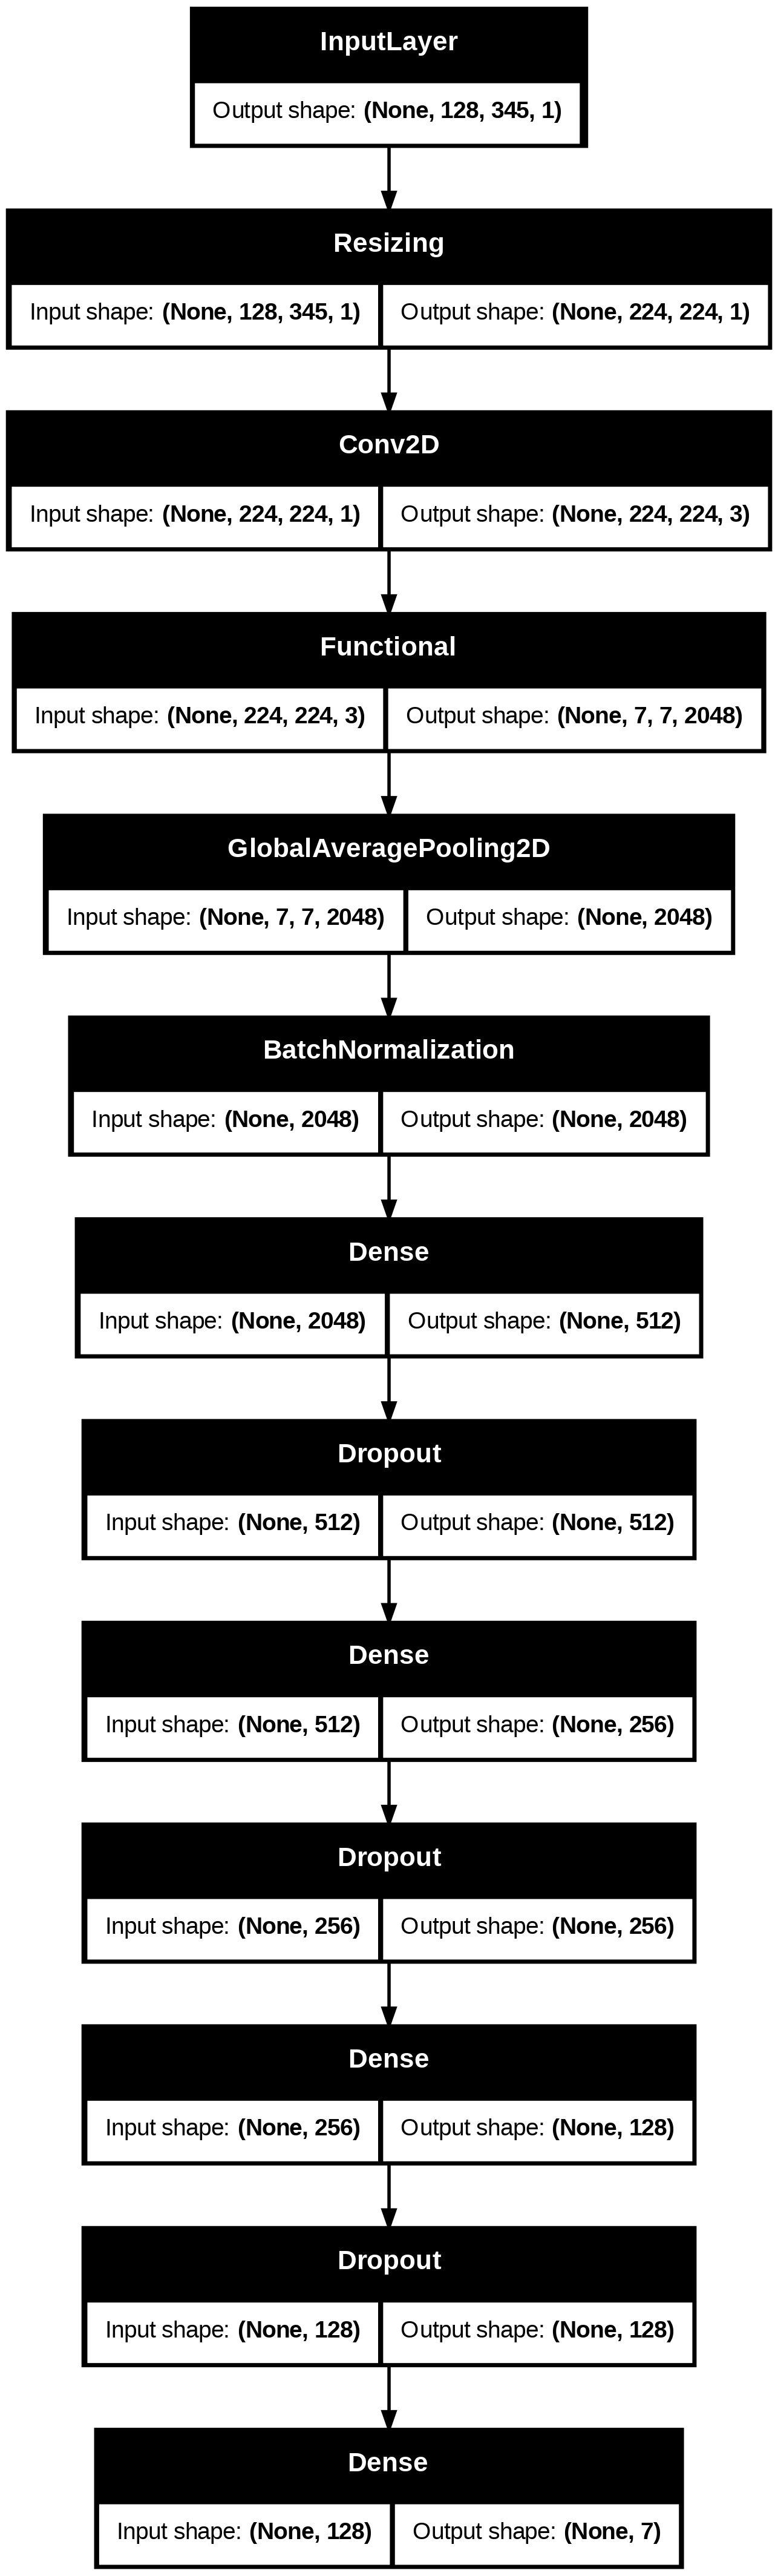

In [36]:
# Plot the model architecture
tf.keras.utils.plot_model(model_mel, show_shapes=True, to_file='model_mel.png')

In [37]:
# Create a callback that stops training when the validation loss plateaus or increases
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode = 'min')

In [38]:
# Create a callback that adjusts the learning rate gradually
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                    factor=0.2,
                                                    min_lr=0.000001,
                                                    patience=3,
                                                    mode='min')

In [39]:
# (a6) Train and evaluate with FROZEN base model, varying number of epochs
# Epoch settings to compare: 10, 15, 20, 50, 100, 150
EPOCH_SETTINGS = [10, 15, 20, 50, 100, 150]
MAX_EPOCHS = max(EPOCH_SETTINGS)

print(f"Training frozen-base model for {MAX_EPOCHS} epochs...")
print("Results will be extracted at each milestone epoch.\n")

# Re-compile with sparse_categorical_crossentropy (labels are integers)
model_mel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Single training run up to MAX_EPOCHS; history contains all epochs
history_mel = model_mel.fit(
    train_dataset_1,
    epochs=MAX_EPOCHS,
    validation_data=test_dataset_1,
    verbose=1
)

# ── (a6) Report performance at each epoch milestone ──────────────────
print("\n" + "="*70)
print("(a6) Frozen-Base Performance at Different Epoch Settings")
print("="*70)
header = f"{'Epochs':<10} {'Train Acc':>12} {'Val Acc':>12} {'Train Loss':>13} {'Val Loss':>12}"
print(header)
print("-"*70)
for ep in EPOCH_SETTINGS:
    idx = ep - 1
    if idx < len(history_mel.history['accuracy']):
        tr_acc  = history_mel.history['accuracy'][idx]
        val_acc = history_mel.history['val_accuracy'][idx]
        tr_loss = history_mel.history['loss'][idx]
        val_loss= history_mel.history['val_loss'][idx]
        print(f"{ep:<10} {tr_acc:>12.4f} {val_acc:>12.4f} {tr_loss:>13.4f} {val_loss:>12.4f}")


Training frozen-base model for 150 epochs...
Results will be extracted at each milestone epoch.

Epoch 1/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 763ms/step - accuracy: 0.3613 - loss: 2.3660 - val_accuracy: 0.1539 - val_loss: 2.6797
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.3753 - loss: 2.2821 - val_accuracy: 0.1739 - val_loss: 2.5650
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.3989 - loss: 2.0168 - val_accuracy: 0.1977 - val_loss: 2.3371
Epoch 4/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.4293 - loss: 1.7904 - val_accuracy: 0.2330 - val_loss: 2.0822
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.4432 - loss: 1.6904 - val_accuracy: 0.2487 - val_loss: 1.9698
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.4555 - loss: 1.6400 - val_accuracy: 0.2527 - val_loss: 1.9273
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.4838 - loss: 1.4766 - val_accuracy: 0.2813 - val_loss: 1.8110

# **This portion contains another code snippet to perform transfer learning and fine-tuning. You can work on this portion as well to attemptr the assignment question parts. Either of these two code snippet portions you can modify to attempt the programming assignment part.**

In [40]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# =========================
# PARAMETERS
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 7

# =========================
# PREPROCESSING FUNCTION
# =========================
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.image.grayscale_to_rgb(image)   # (H,W,1) → (H,W,3)
    image = preprocess_input(image)
    return image, label

# =========================
# DATASET PREPARATION
# =========================
train_data = tf.data.Dataset.from_tensor_slices((X_train_1, y_train_1))
val_data   = tf.data.Dataset.from_tensor_slices((X_test_1, y_test_1))

train_data = train_data.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_data   = val_data.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# =========================
# LOAD PRETRAINED MODEL
# =========================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# =========================
# PHASE 1: FREEZE BASE MODEL
# =========================
for layer in base_model.layers:
    layer.trainable = False

# =========================
# BUILD MODEL
# =========================
x = base_model.output

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(512, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

# =========================
# COMPILE (PHASE 1)
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(), #loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=5, verbose=1)
]

# =========================
# TRAIN (PHASE 1)
# =========================
print("\nStarting Phase 1 (Frozen Base Model)...\n")

history_phase1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=callbacks
)

# =========================
# PHASE 2: FINE-TUNING
# =========================
print("\nStarting Phase 2 (Fine-Tuning)...\n")

# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile with LOW learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(), #loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Train again
history_phase2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=callbacks
)

# =========================
# PLOTTING RESULTS
# =========================
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(title + " Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(title + " Loss")
    plt.legend()

    plt.show()

plot_history(history_phase1, "Phase 1")
plot_history(history_phase2, "Phase 2")


Starting Phase 1 (Frozen Base Model)...

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 513ms/step - accuracy: 0.3591 - loss: 2.3841 - val_accuracy: 0.1558 - val_loss: 2.6709 - learning_rate: 0.0010
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.3651 - loss: 2.2618 - val_accuracy: 0.1637 - val_loss: 2.6308 - learning_rate: 0.0010
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.3723 - loss: 2.0717 - val_accuracy: 0.1778 - val_loss: 2.4876 - learning_rate: 0.0010
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.3827 - loss: 1.9336 - val_accuracy: 0.1924 - val_loss: 2.3827 - learning_rate: 0.0010
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.3905 - loss: 1.8486 - val_accuracy: 0.1972 - val_loss: 2.3019 - learning_rate: 0.0010
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.3919 - loss: 1.7586 - val_accuracy: 0.1987 - val_loss: 2.2843 - learning_rate: 0.0010
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 110m

<Figure size 1680x560 with 2 Axes>

<Figure size 1680x560 with 2 Axes>

In [41]:
# Save the model
model_mel.save('emotion_recognition_mel_spec.keras')

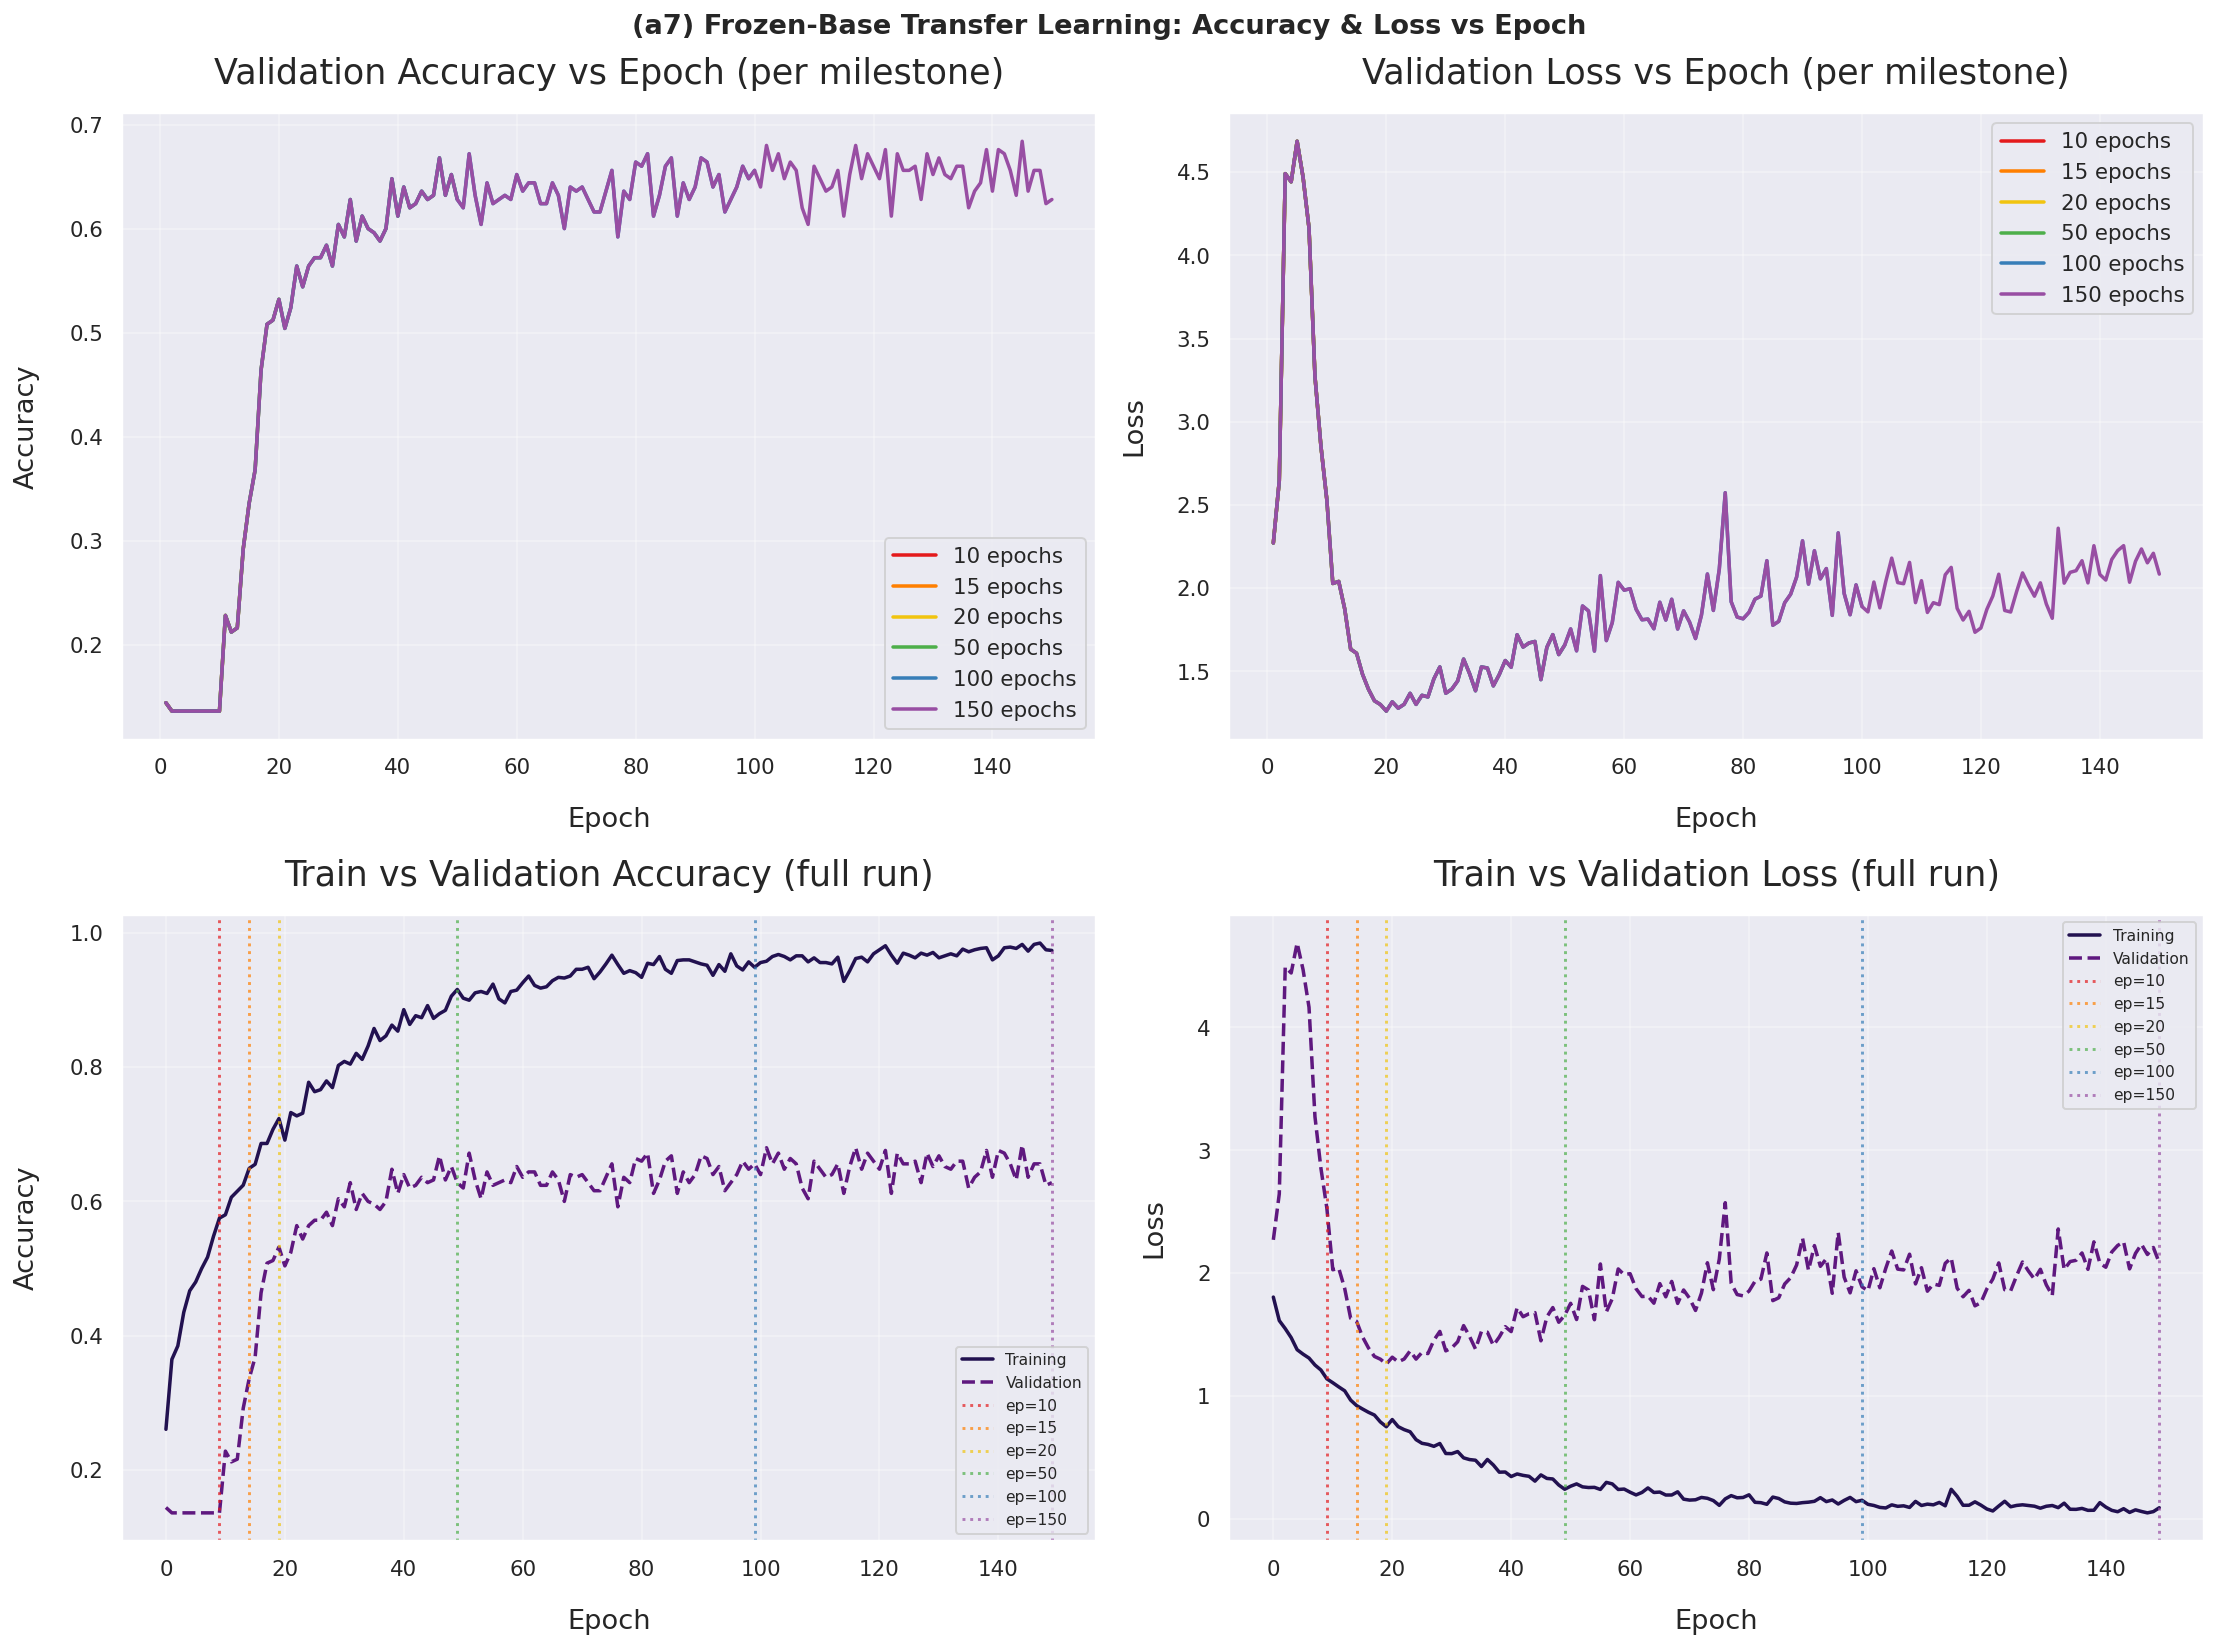


(a7) Interpretation:
- Accuracy typically rises steeply in early epochs (10-20), then plateaus or overfits.
- Loss should decrease consistently; divergence between train/val loss signals overfitting.
- Milestone markers show where each epoch-setting experiment would have stopped.
- Longer training (100-150) may not always improve val accuracy with a frozen backbone,
  since the FC head has limited capacity to learn without backbone fine-tuning.


In [42]:
# (a7) Plot accuracy vs epoch and loss vs epoch for different epoch settings
import matplotlib.pyplot as plt

EPOCH_SETTINGS = [10, 15, 20, 50, 100, 150]
colors = ['#e41a1c', '#ff7f00', '#f1c40f', '#4daf4a', '#377eb8', '#984ea3']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('(a7) Frozen-Base Transfer Learning: Accuracy & Loss vs Epoch', fontsize=14, fontweight='bold')

# ── Top row: full curves up to each milestone (validation) ───────────
ax_acc  = axes[0, 0]
ax_loss = axes[0, 1]

for ep, color in zip(EPOCH_SETTINGS, colors):
    end_idx = min(ep, len(history_mel.history['val_accuracy']))
    ax_acc.plot( range(1, end_idx + 1),
                 history_mel.history['val_accuracy'][:end_idx],
                 label=f'{ep} epochs', color=color, linewidth=1.8)
    ax_loss.plot(range(1, end_idx + 1),
                 history_mel.history['val_loss'][:end_idx],
                 label=f'{ep} epochs', color=color, linewidth=1.8)

ax_acc.set_title('Validation Accuracy vs Epoch (per milestone)')
ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
ax_acc.legend(loc='lower right'); ax_acc.grid(True, alpha=0.3)

ax_loss.set_title('Validation Loss vs Epoch (per milestone)')
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
ax_loss.legend(loc='upper right'); ax_loss.grid(True, alpha=0.3)

# ── Bottom row: train vs val at full 150-epoch run ───────────────────
ax_tr_acc  = axes[1, 0]
ax_tr_loss = axes[1, 1]

ax_tr_acc.plot(history_mel.history['accuracy'],     label='Training',   linewidth=1.8)
ax_tr_acc.plot(history_mel.history['val_accuracy'], label='Validation', linewidth=1.8, linestyle='--')
# Mark the milestone epochs
for ep, color in zip(EPOCH_SETTINGS, colors):
    idx = ep - 1
    if idx < len(history_mel.history['val_accuracy']):
        ax_tr_acc.axvline(x=idx, color=color, linestyle=':', alpha=0.7, label=f'ep={ep}')
ax_tr_acc.set_title('Train vs Validation Accuracy (full run)')
ax_tr_acc.set_xlabel('Epoch'); ax_tr_acc.set_ylabel('Accuracy')
ax_tr_acc.legend(loc='lower right', fontsize=8); ax_tr_acc.grid(True, alpha=0.3)

ax_tr_loss.plot(history_mel.history['loss'],     label='Training',   linewidth=1.8)
ax_tr_loss.plot(history_mel.history['val_loss'], label='Validation', linewidth=1.8, linestyle='--')
for ep, color in zip(EPOCH_SETTINGS, colors):
    idx = ep - 1
    if idx < len(history_mel.history['val_loss']):
        ax_tr_loss.axvline(x=idx, color=color, linestyle=':', alpha=0.7, label=f'ep={ep}')
ax_tr_loss.set_title('Train vs Validation Loss (full run)')
ax_tr_loss.set_xlabel('Epoch'); ax_tr_loss.set_ylabel('Loss')
ax_tr_loss.legend(loc='upper right', fontsize=8); ax_tr_loss.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n(a7) Interpretation:")
print("- Accuracy typically rises steeply in early epochs (10-20), then plateaus or overfits.")
print("- Loss should decrease consistently; divergence between train/val loss signals overfitting.")
print("- Milestone markers show where each epoch-setting experiment would have stopped.")
print("- Longer training (100-150) may not always improve val accuracy with a frozen backbone,")
print("  since the FC head has limited capacity to learn without backbone fine-tuning.")


In [43]:
# Measure the precision and recall
y_pred = model_mel.predict(X_test_1)
# Convert the predictions into one-hot encoded vectors
y_pred = np.argmax(y_pred, axis=1)
# Plot the classification report
print(classification_report(y_test_1, y_pred, target_names=encoder.classes_))

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 626ms/step
              precision    recall  f1-score   support

       anger       0.83      0.82      0.83        34
     disgust       0.80      0.72      0.76        32
        fear       0.74      0.70      0.72        43
   happiness       0.72      0.78      0.75        36
     neutral       0.71      0.78      0.74        23
     sadness       0.68      0.71      0.70        35
    surprise       0.87      0.89      0.88        47

    accuracy                           0.78       250
   macro avg       0.76      0.77      0.77       250
weighted avg       0.78      0.78      0.77       250



8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


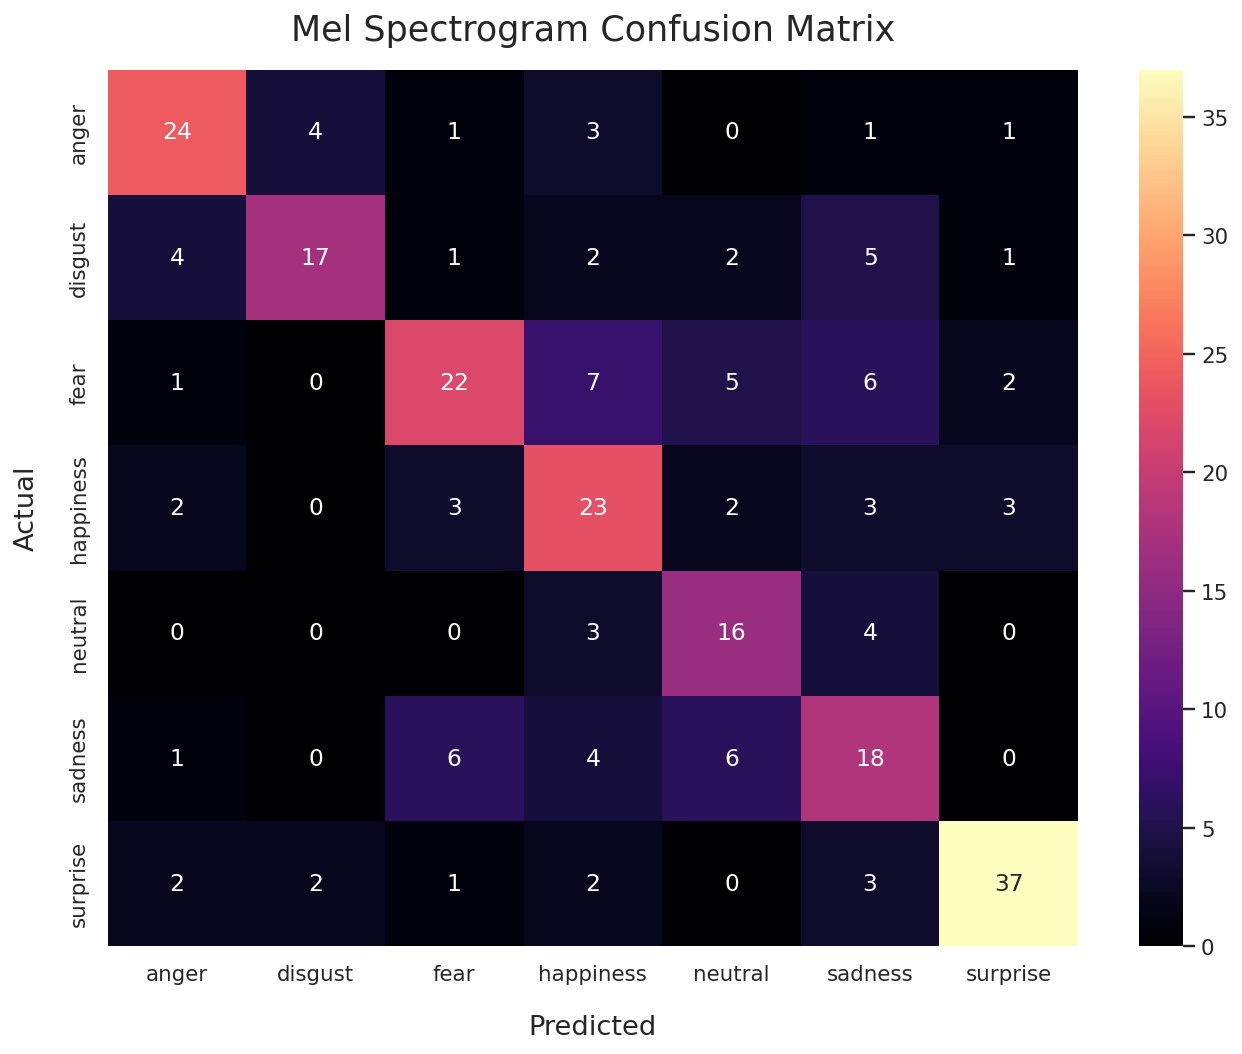

In [44]:
# Plot the confusion matrix for the validation set
# Get the predictions for the test data
y_pred = model_mel.predict(X_test_1)
# Convert the predictions into one-hot encoded vectors
y_pred = np.argmax(y_pred, axis=1)
# Get the confusion matrix
cm = tf.math.confusion_matrix(y_test_1, y_pred)
# Plot the confusion matrix
plt.figure(figsize=(10, 8))
# Make the index and column labels the emotion names
cm = pd.DataFrame(cm.numpy(), index=encoder.classes_, columns=encoder.classes_)
sns.heatmap(cm, annot=True, fmt='', cmap='magma')
plt.title('Mel Spectrogram Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout(pad=2)


As we can see, the model achieves around 76–78% validation accuracy after fine-tuning. This is a great accuracy for such a complex task, as it is hard for even a human to recognize a very specific emotion from an audio file 2-4 seconds long.

Another metric that we can use is MFCCs, or Mel Frequency Cepstral Coefficients, which extracts features from the audio files. This is a common technique used in speech recognition, and it is known to work well. Let's see if it can improve our validation accuracy and loss.

MFCCs are generated by applying the Discrete Cosine Transform (DCT) to the Mel Spectrogram. The DCT is similar to the Fourier Transform, but it only uses real numbers. The DCT is applied to the Mel Spectrogram by applying it to each frequency bin of the Mel Spectrogram. The result is a set of coefficients that represent the power of the signal in each frequency bin.

MFCCs are commonly used in speech recognition because they are a good representation of the vocal tract and the vocal tract shape.

This makes MFCCs the state of the art technique for speech recognition. We used 128 MFCCs to make it more similar to the Mel Spectrograms and less prone to overfitting. However, we could have used fewer MFCCs, as the first 20-30 MFCCs are the most important.

This [review](https://ieeexplore.ieee.org/abstract/document/9955539) explains MFCCs and its performance in many applications in more detail.

We will also treat the MFCCs as images and use a CNN to classify them.